Module importing

In [2]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from lstm_unet import lstm_unet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_11064\3262518157.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = "AR")


414
torch.Size([1, 800])


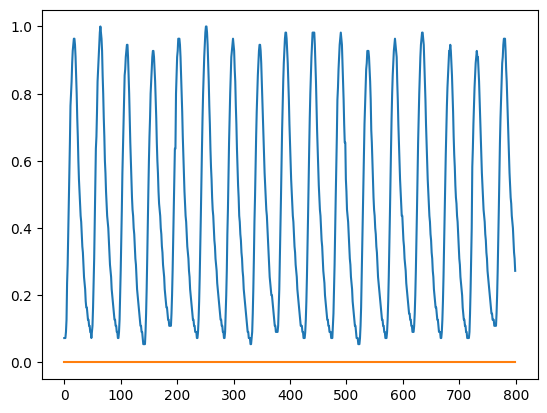

[1024, 512, 256, 128, 64]
[[[100, 64], [64, 128], [128, 256], [256, 512]], [3, 3, 3, 3], [1.0, 1.0, 1.0, 1.0]]
[[512, 512], 3, 1.0]
[[[1024, 256], [512, 128], [256, 64], [128, 1]], [3, 3, 3, 3], [1.0, 1.0, 1.0, 1.0]]
[[4, 4, 4, 4], [2, 2, 2, 2], [1.0, 1.0, 1.0, 1.0]]
[[2, 2, 2, 2], [2, 2, 2, 2], [0.0, 0.0, 0.0, 0.0]]


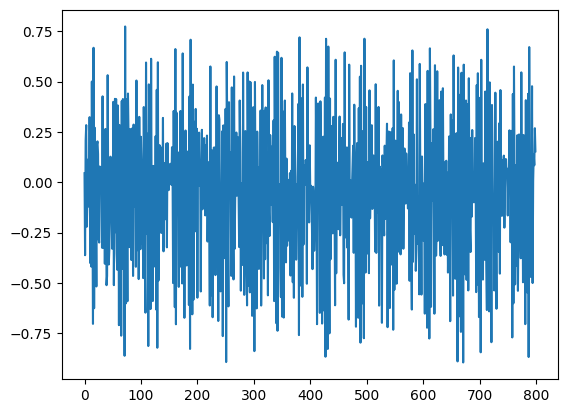

In [4]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = "AR")
print(dataset.count)

print(dataset[100][0].shape)
for i in [400]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         1024,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [4,4,4,4],
            "Kernel decoder":       [2,2,2,2],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }


model = lstm_unet(para = para)
model.structure_calculate(True)
y = model(dataset[1][0].unsqueeze(1))
plt.plot(y.cpu().detach().numpy().flatten())

plt.show()

Training

In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         1024,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [4,4,4,4],
            "Kernel decoder":       [2,2,2,2],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = lstm_unet(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=1000,batch=64,visualize=1)

True
Iteration: 1/1000. loss_train: 0.43065235018730164. loss_val: 0
Iteration: 2/1000. loss_train: 0.3941156268119812. loss_val: 0
Iteration: 3/1000. loss_train: 0.3896035850048065. loss_val: 0
Iteration: 4/1000. loss_train: 0.38393497467041016. loss_val: 0
Iteration: 5/1000. loss_train: 0.3796542286872864. loss_val: 0
Iteration: 6/1000. loss_train: 0.37726014852523804. loss_val: 0
Iteration: 7/1000. loss_train: 0.37597087025642395. loss_val: 0
Iteration: 8/1000. loss_train: 0.37223872542381287. loss_val: 0
Iteration: 9/1000. loss_train: 0.37164634466171265. loss_val: 0
Iteration: 10/1000. loss_train: 0.36561325192451477. loss_val: 0
Iteration: 11/1000. loss_train: 0.3660399615764618. loss_val: 0
Iteration: 12/1000. loss_train: 0.36384692788124084. loss_val: 0
Iteration: 13/1000. loss_train: 0.363331139087677. loss_val: 0
Iteration: 14/1000. loss_train: 0.35822948813438416. loss_val: 0
Iteration: 15/1000. loss_train: 0.3583994507789612. loss_val: 0
Iteration: 16/1000. loss_train: 0.35

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_11064\2016691289.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  1.0061374
Mean loss:  0.18282813
Min loss:  0.007453191
Number of test:  88


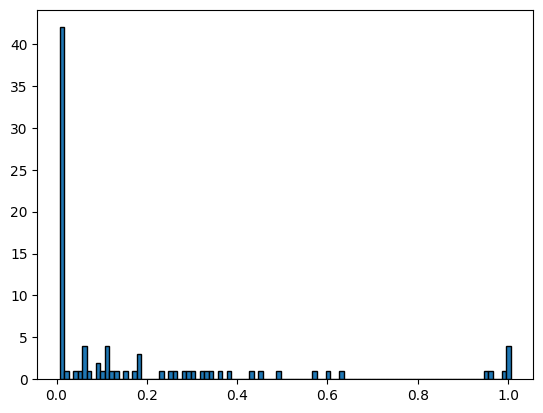

0.42761743


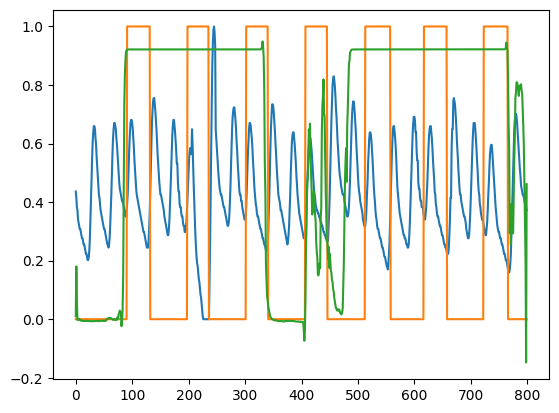

0.11750649


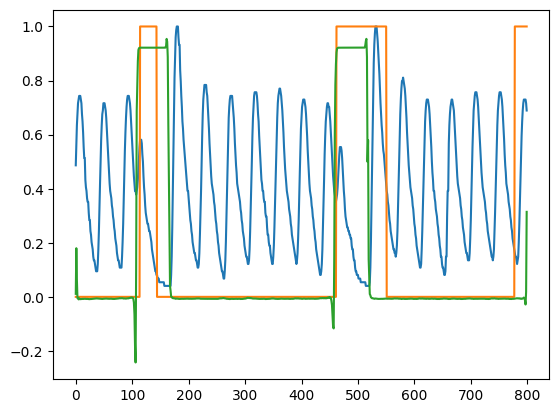

0.11325776


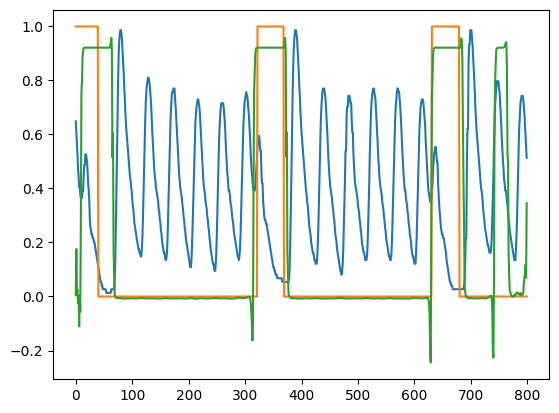

0.14789292


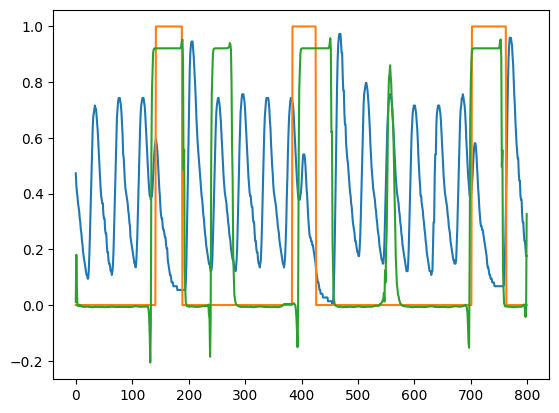

0.00759624


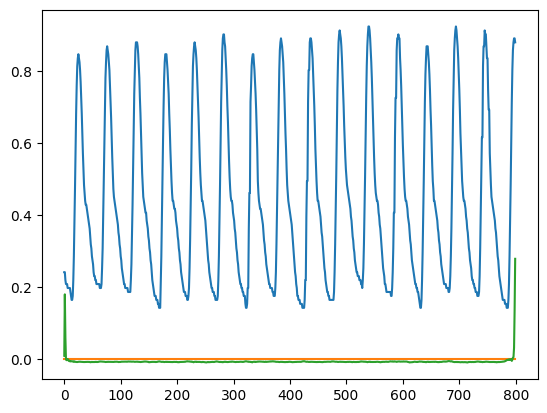

0.007917628


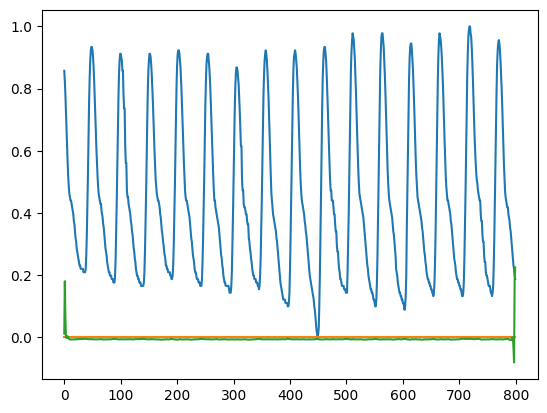

0.048144903


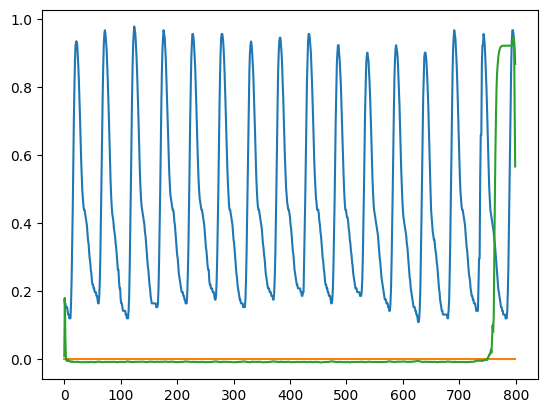

0.060397785


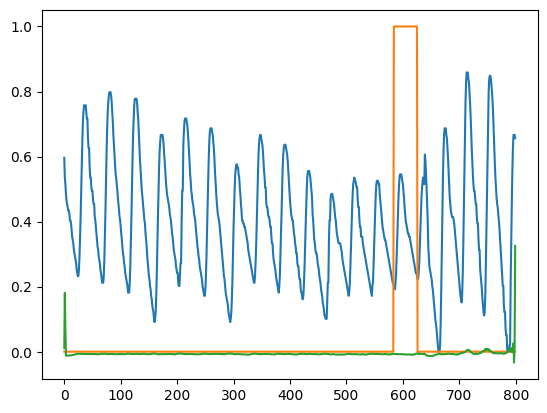

0.058304753


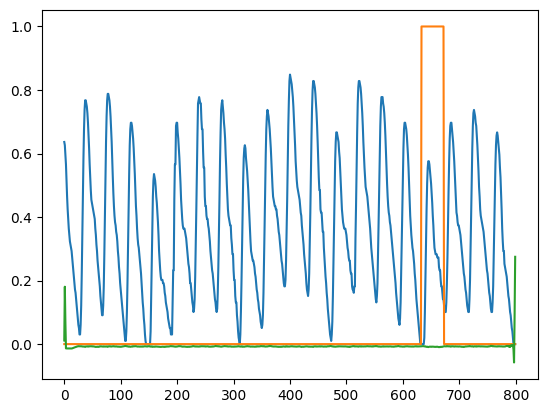

0.008372167


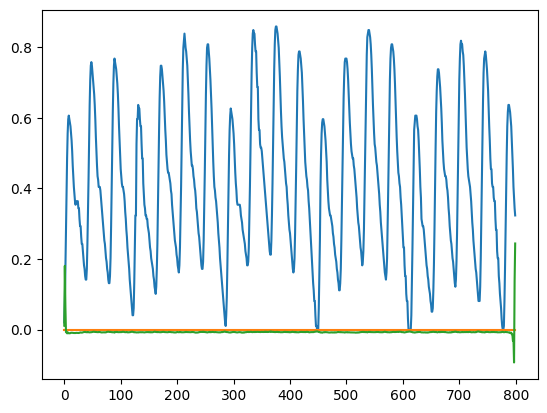

0.007520685


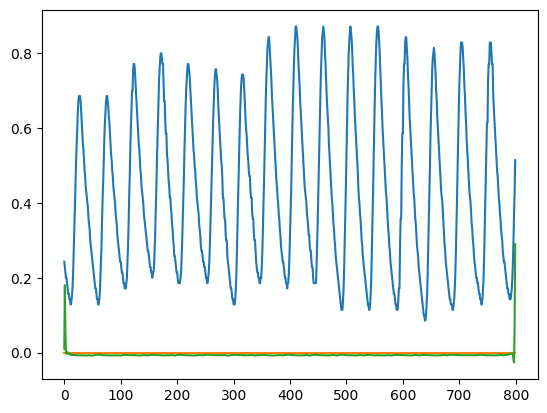

0.0076938593


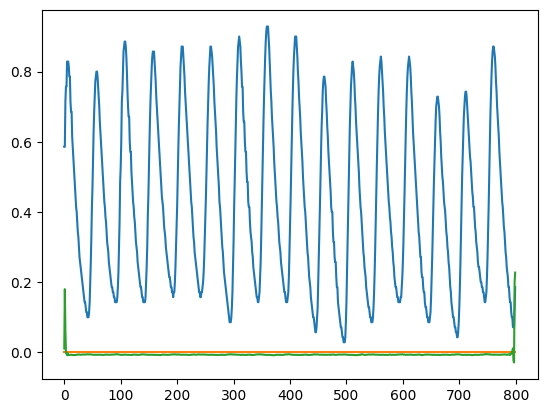

0.0076638935


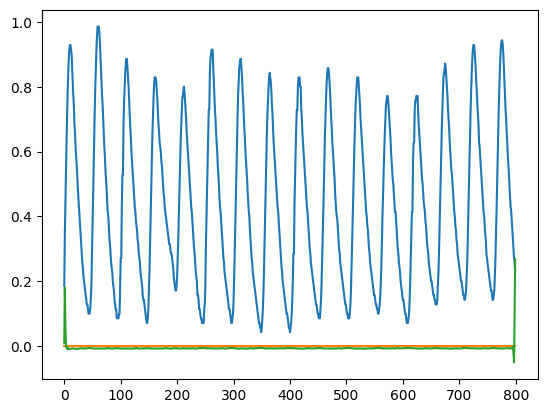

0.008603111


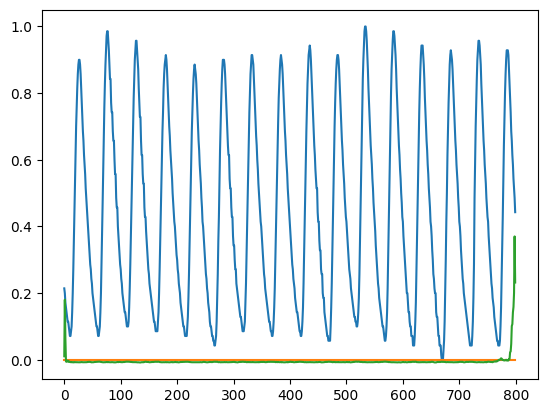

0.0077671646


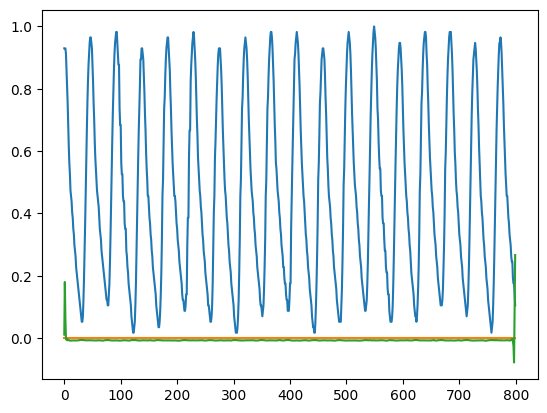

0.007706357


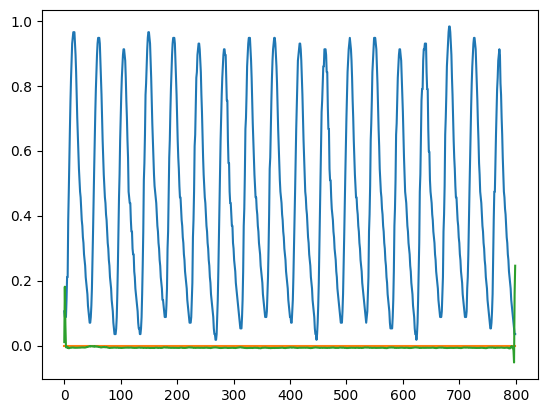

0.0078588035


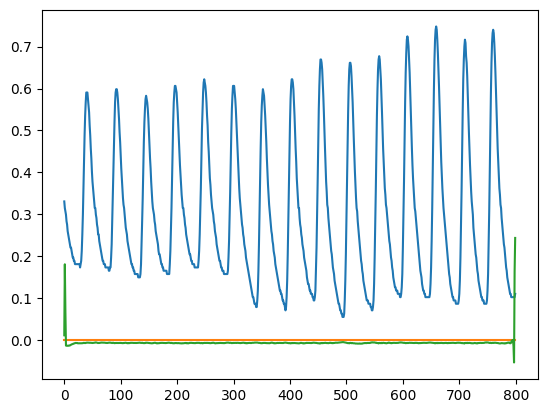

0.16797511


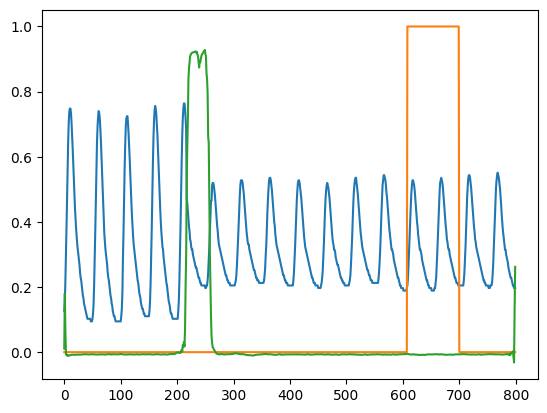

0.24909198


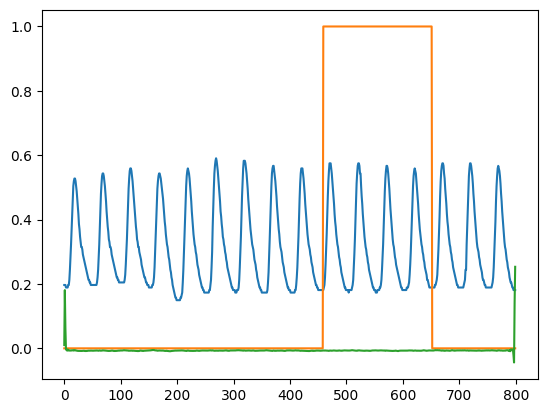

0.17768683


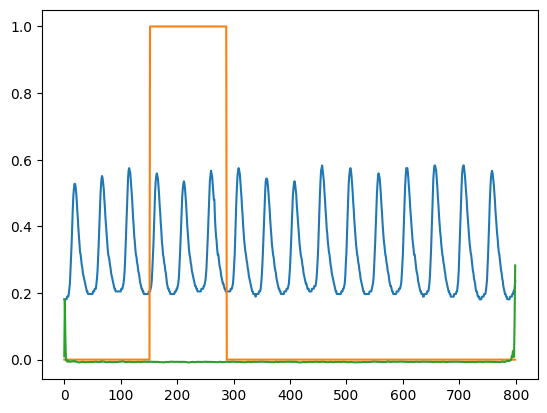

0.061800897


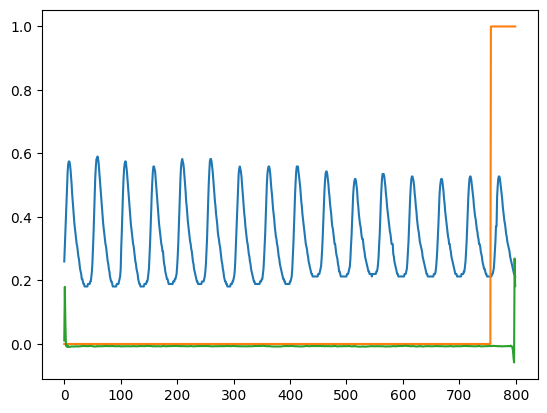

0.30184916


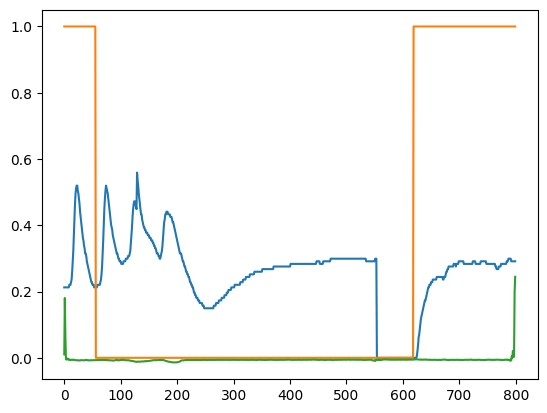

0.4545649


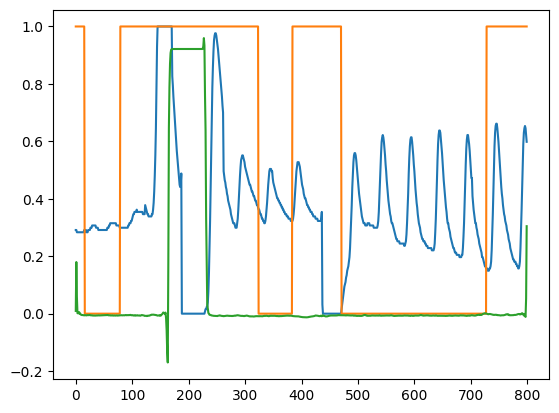

0.34603134


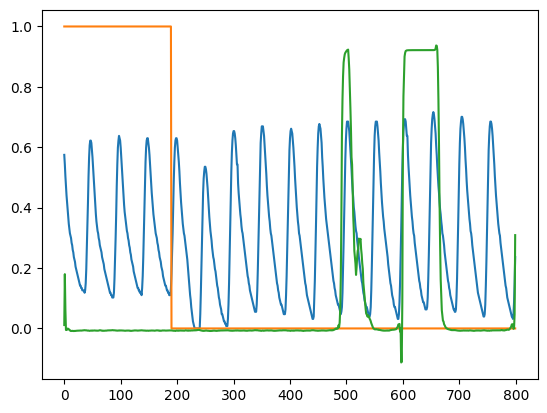

0.3810934


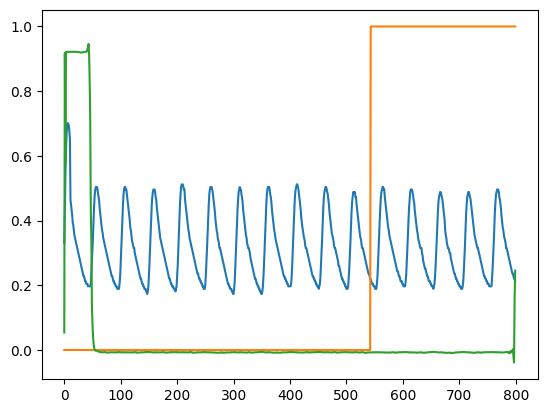

0.007453191


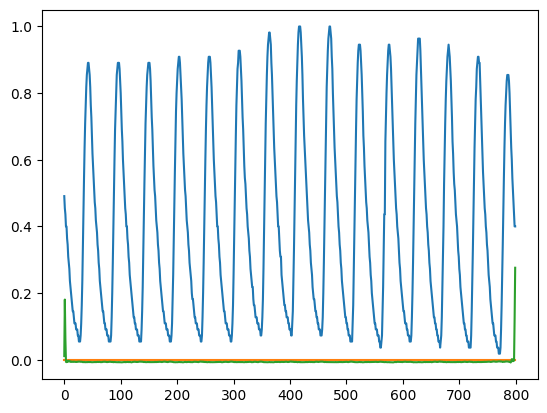

0.0074668108


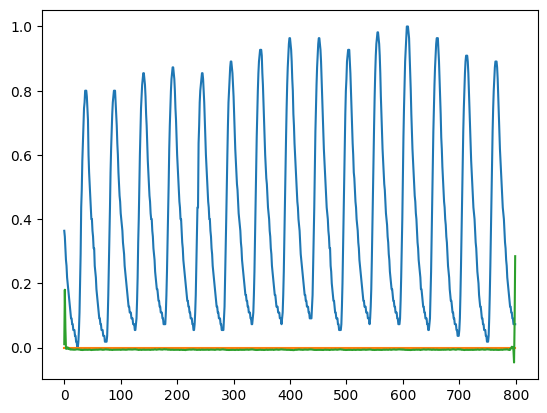

0.0076033785


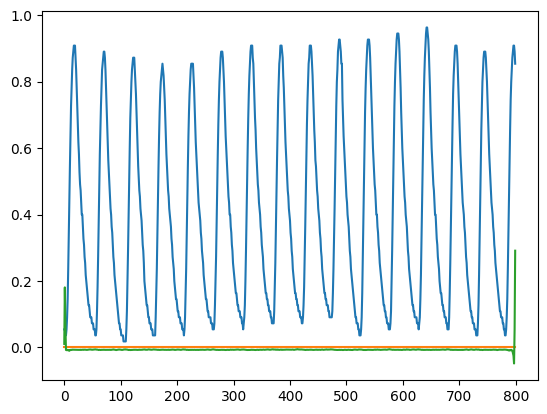

0.0075019393


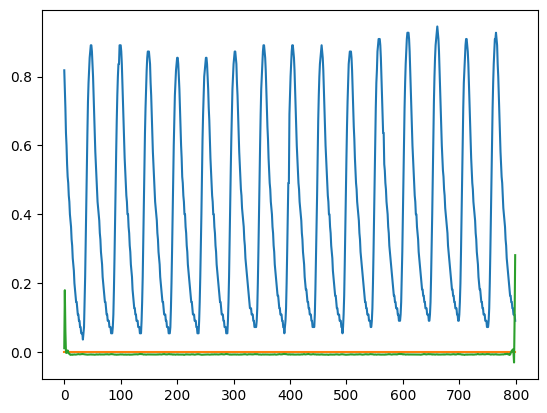

0.046429507


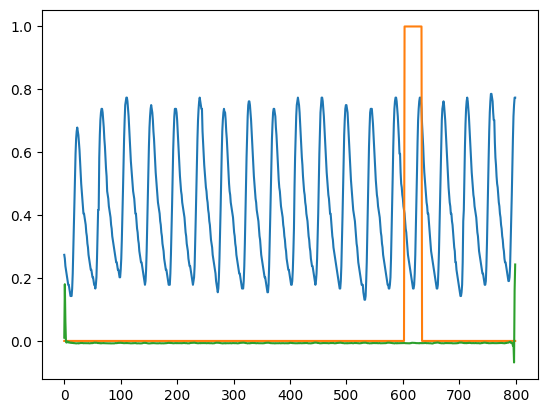

0.18267287


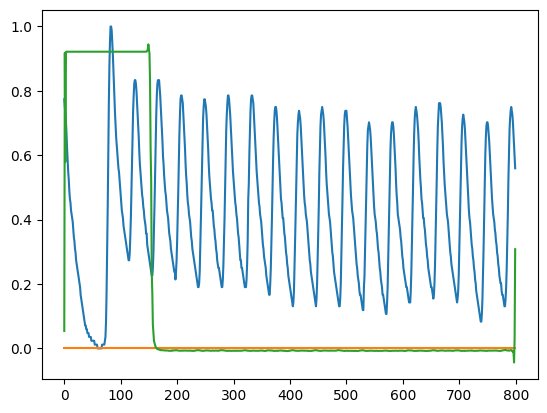

0.0078054424


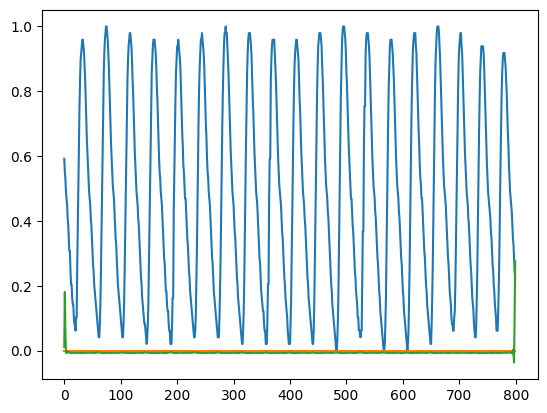

0.007901018


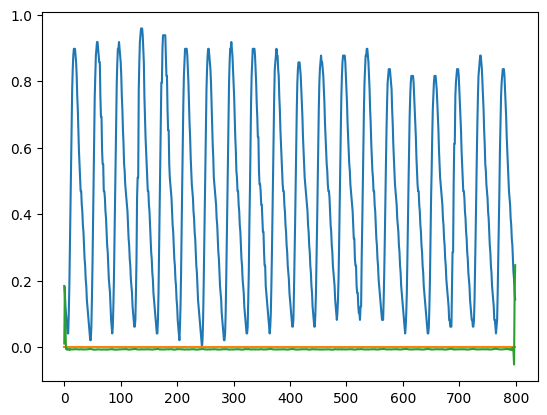

0.0076415325


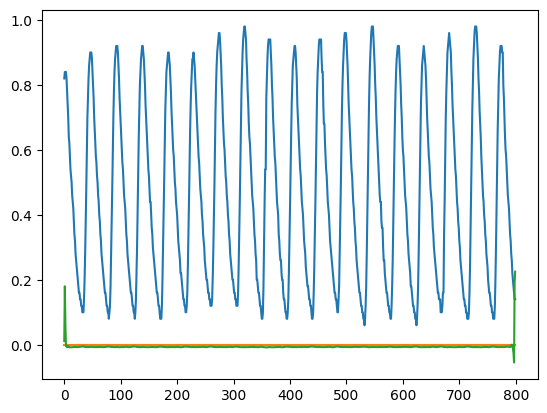

0.007538328


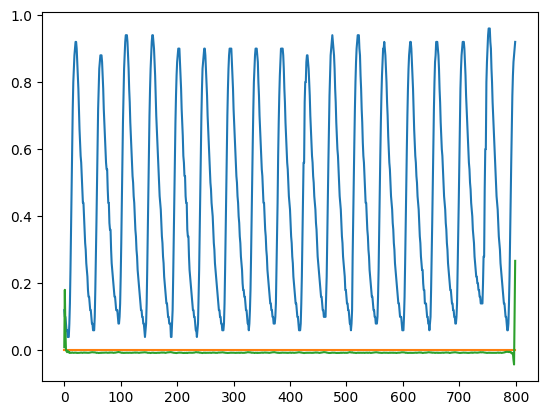

0.007565081


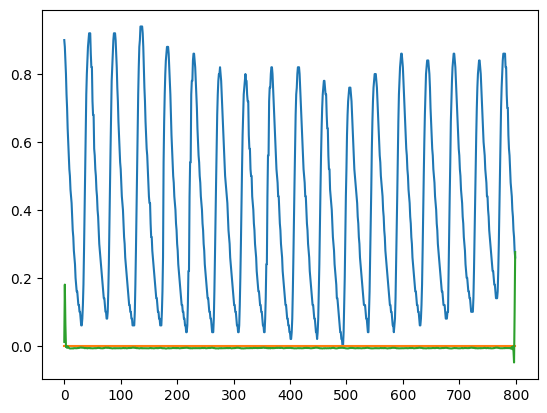

0.49259862


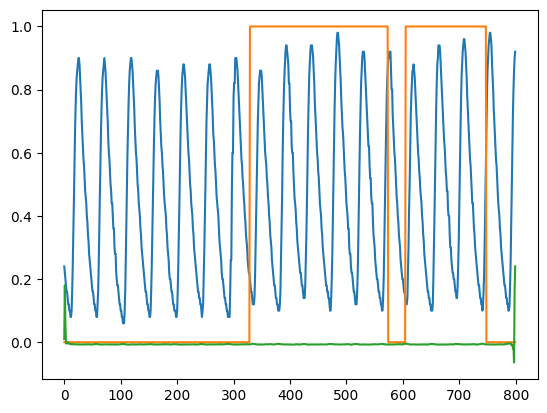

0.2276477


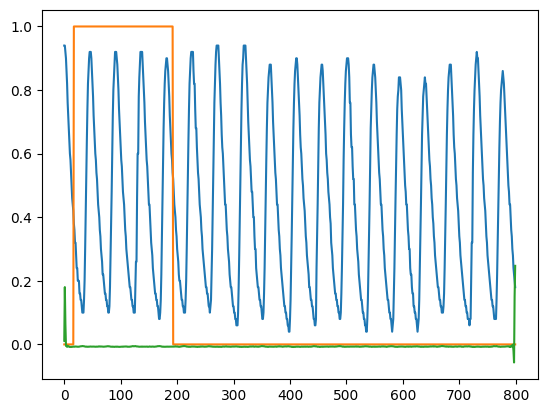

0.0075288736


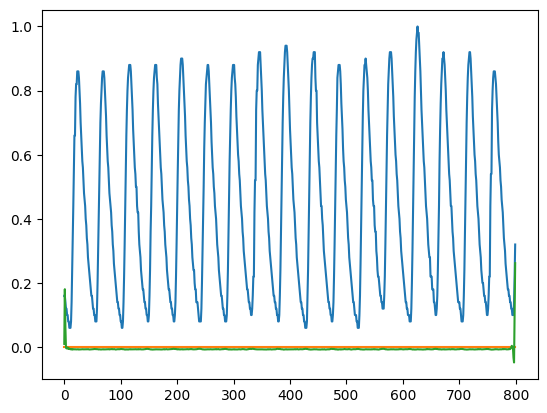

0.0075772875


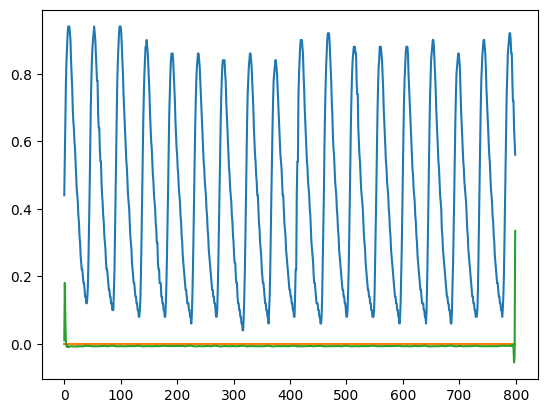

0.007840009


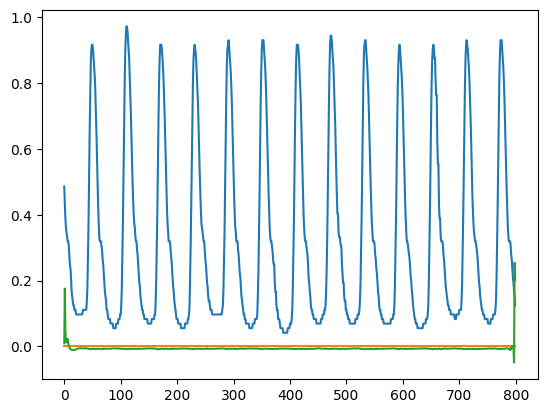

0.016288059


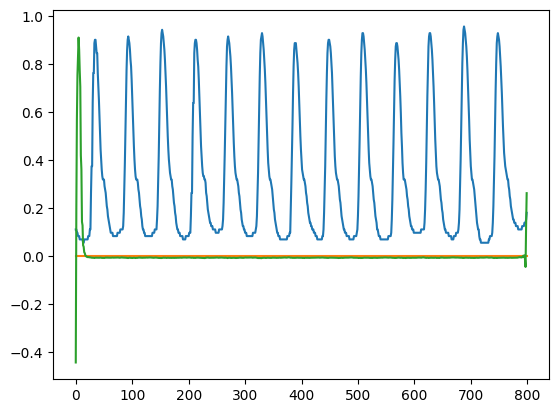

0.0076504895


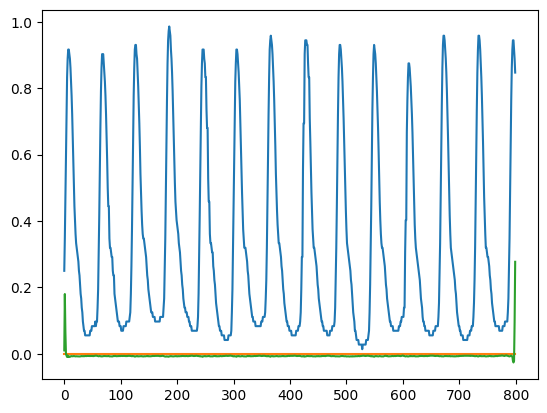

0.007815376


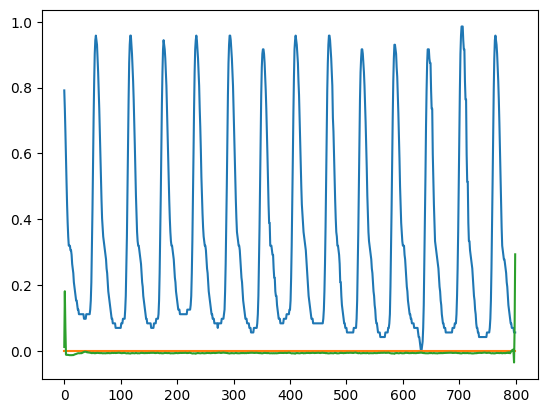

0.007684536


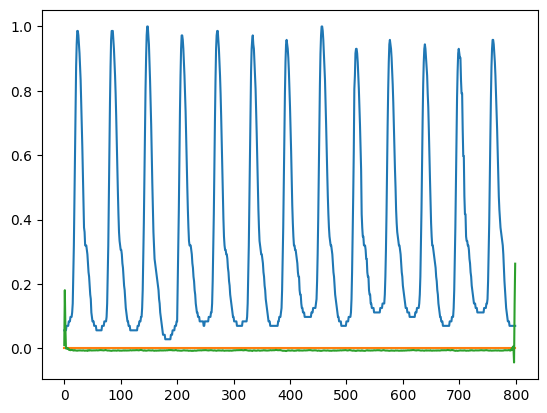

0.0076154373


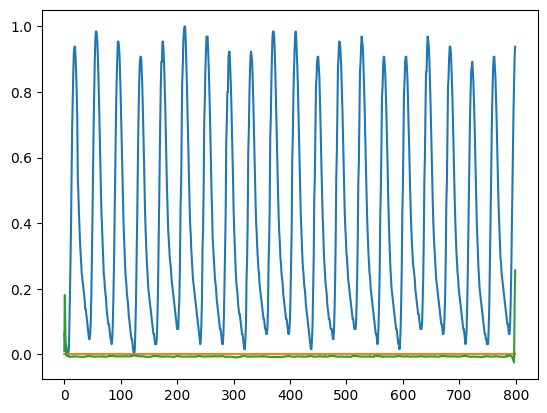

0.007930091


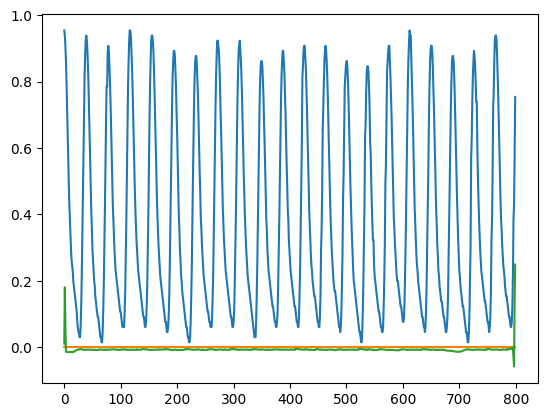

0.008215275


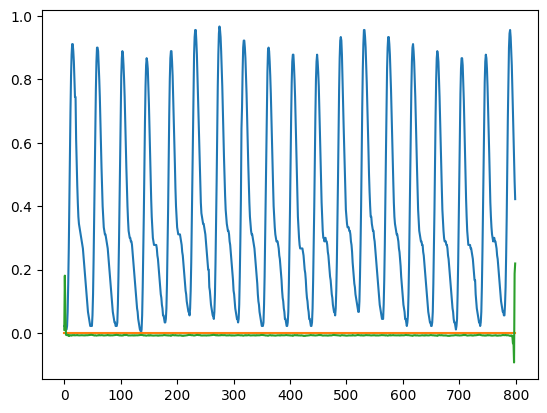

0.29388064


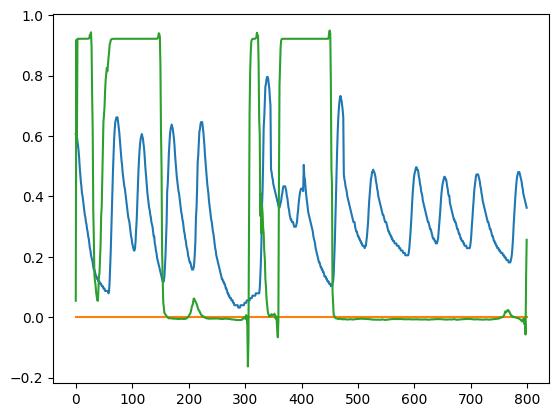

0.6011461


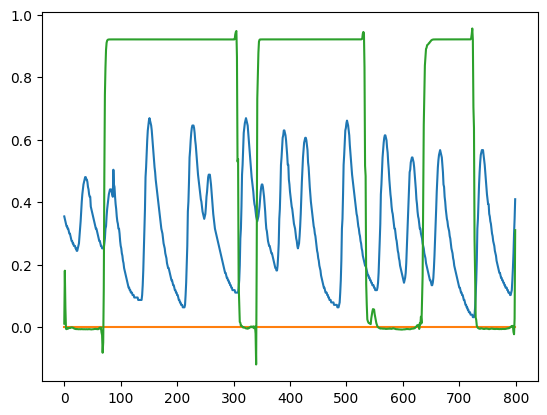

0.31936264


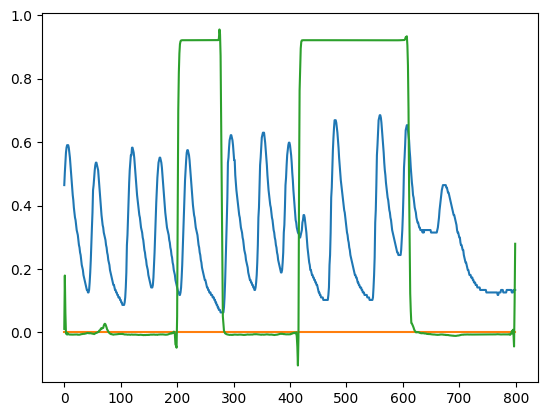

0.0074775284


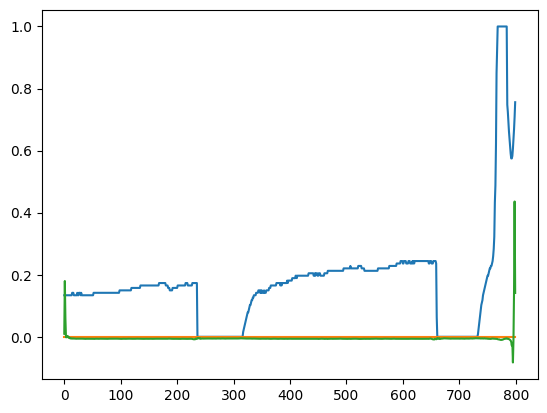

0.36118945


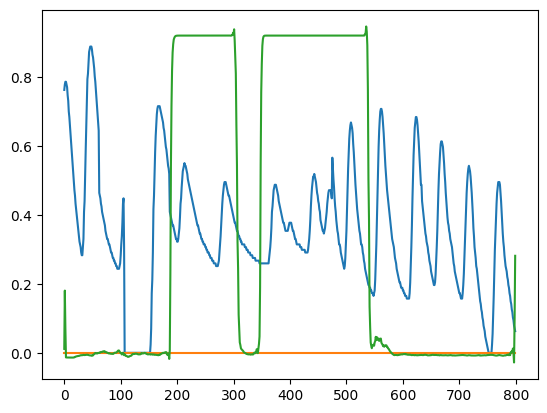

0.26143357


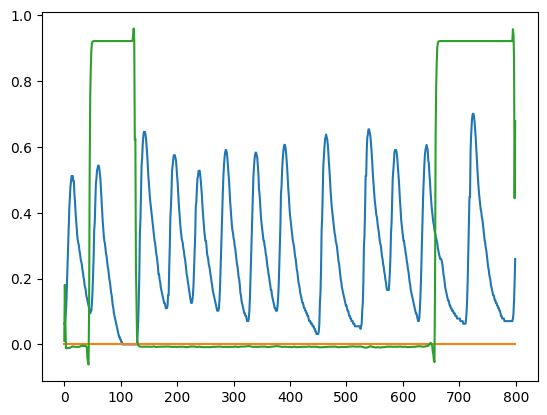

0.09051897


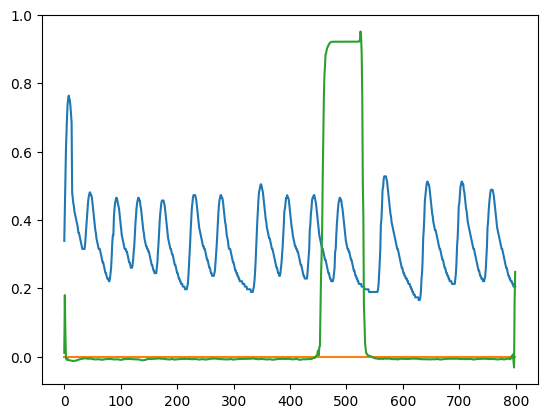

0.112129174


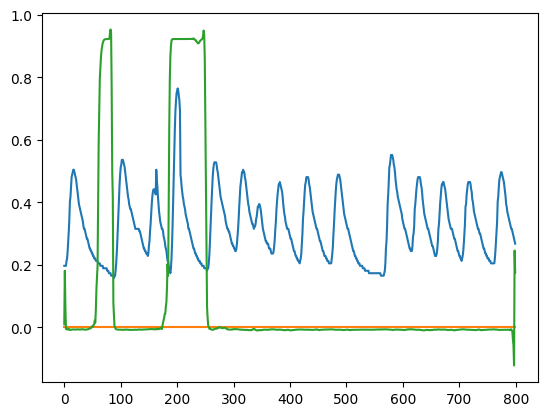

0.33689034


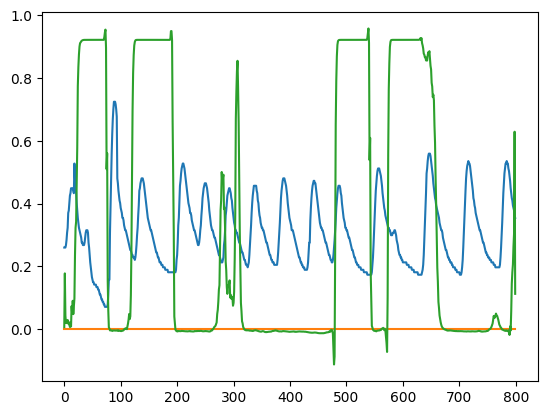

0.18468864


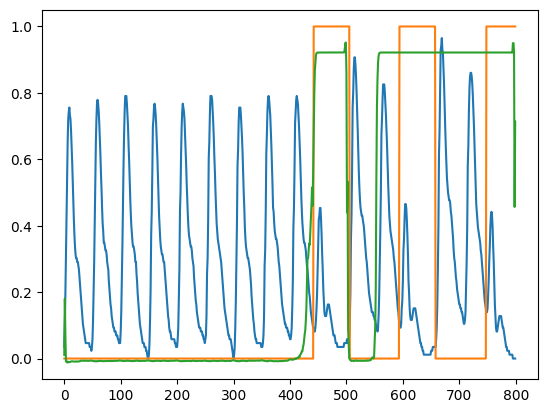

0.11555734


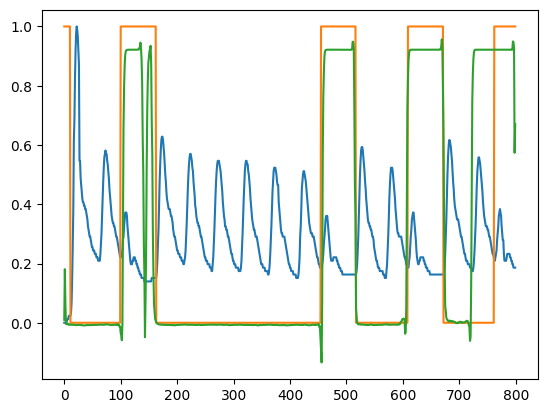

0.0077287704


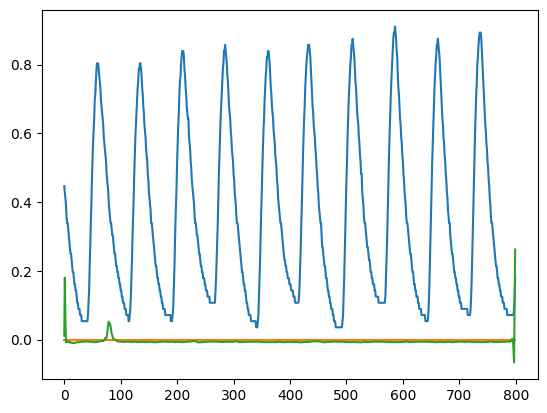

0.061266836


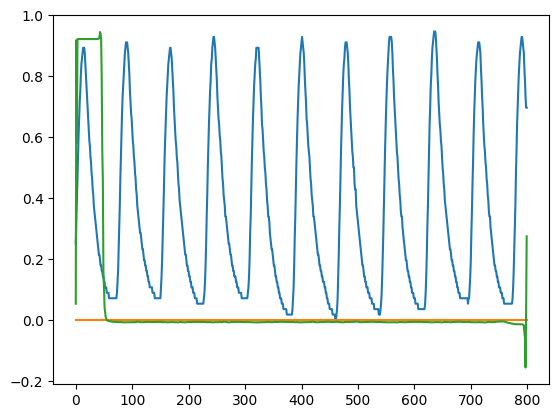

0.016981876


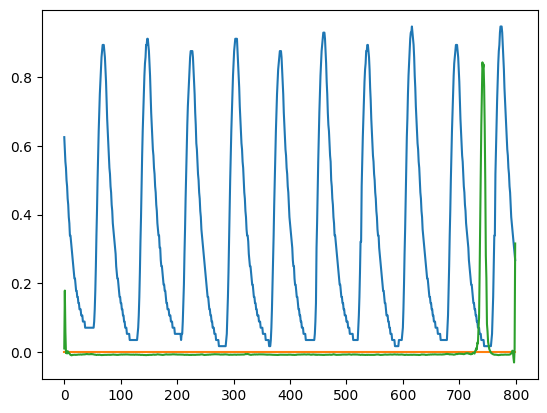

0.007464909


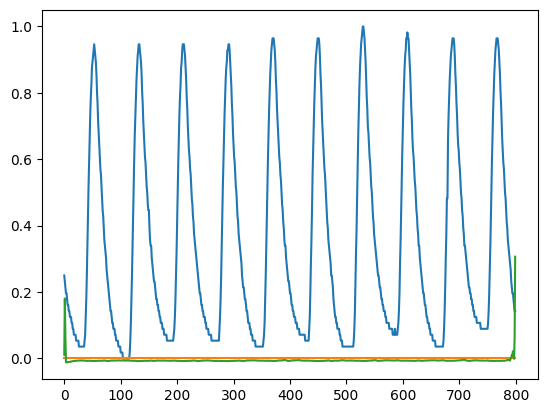

0.2816963


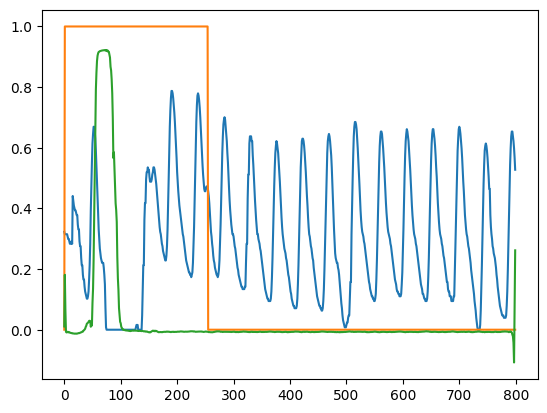

0.00788322


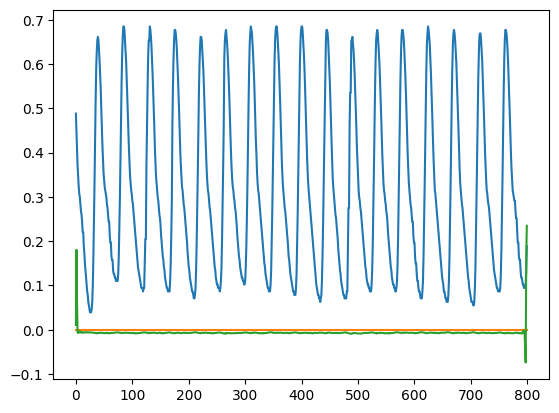

0.9470984


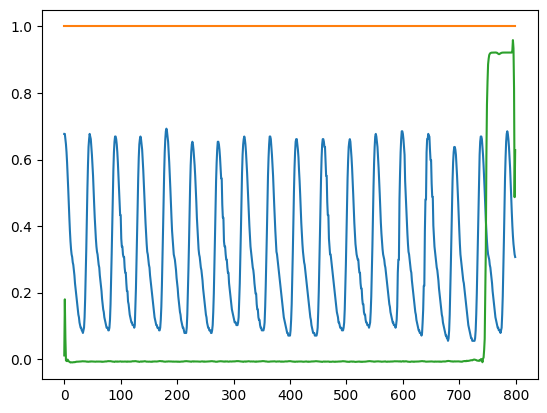

1.0061374


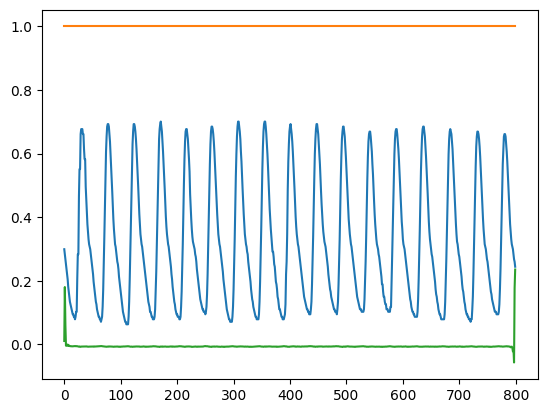

1.0033908


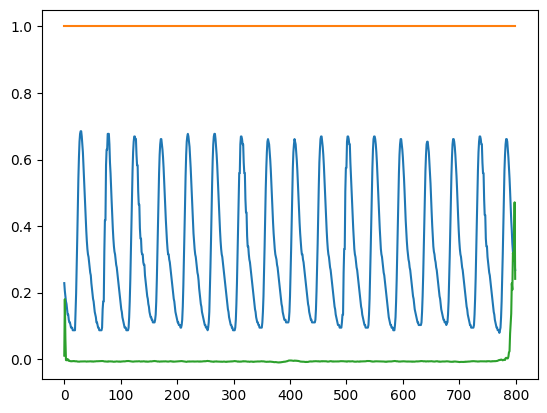

1.0059438


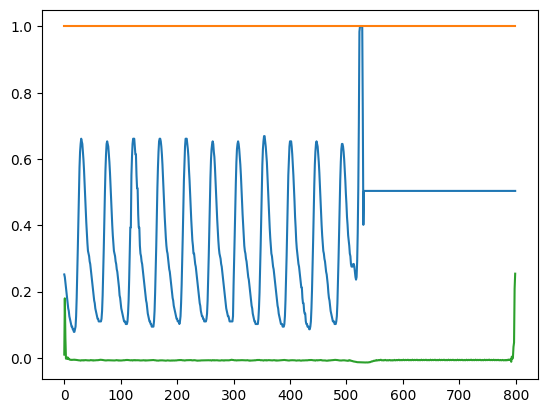

1.005271


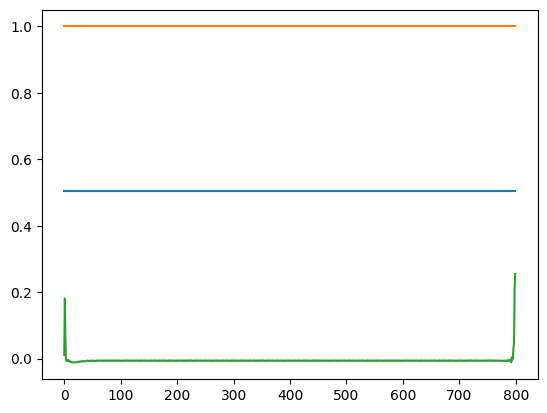

0.11524668


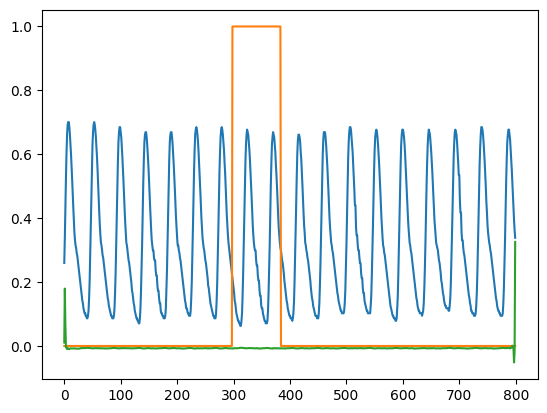

0.07669806


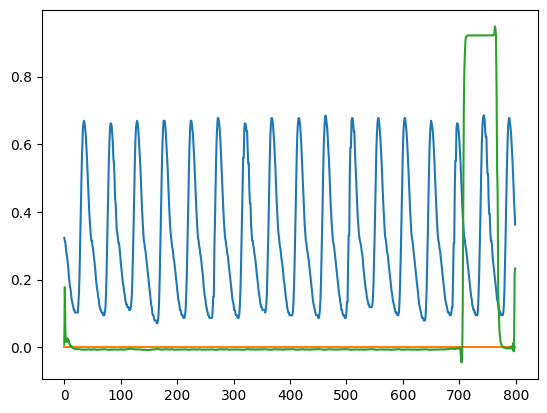

0.007614454


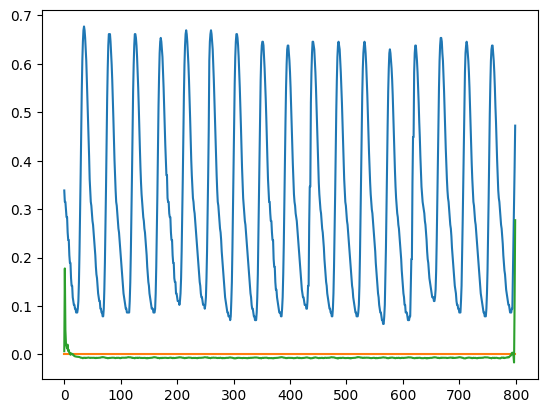

0.5738606


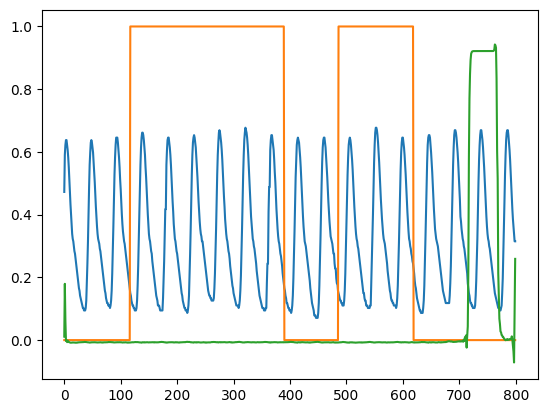

0.6266869


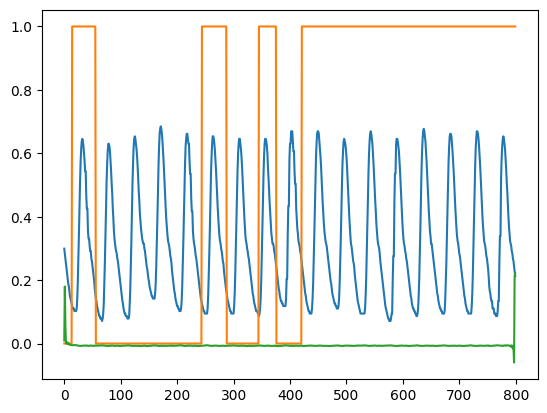

0.13487555


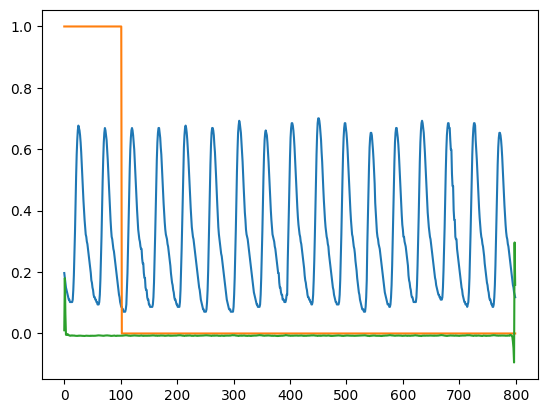

0.007841889


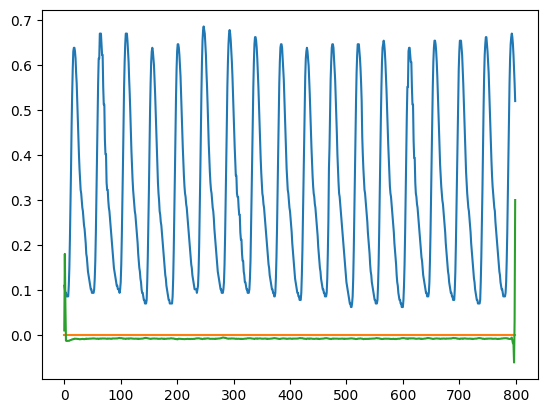

0.08798065


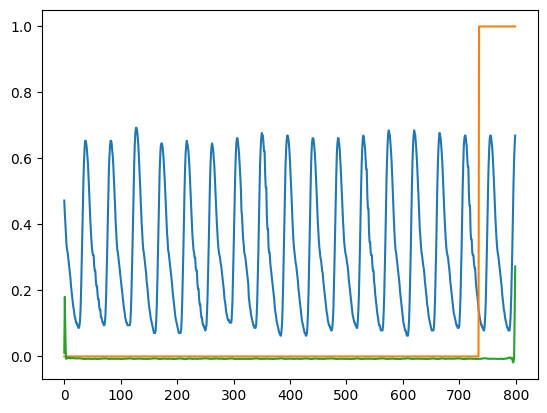

0.007961177


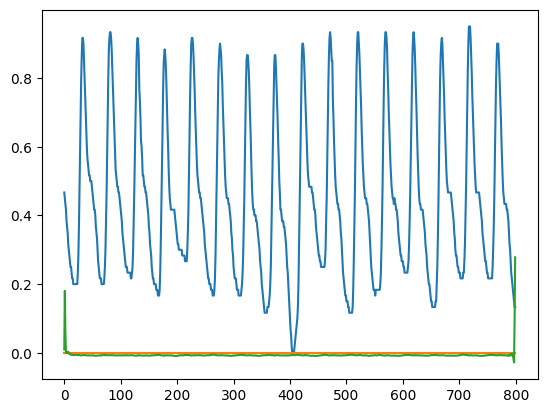

0.020464908


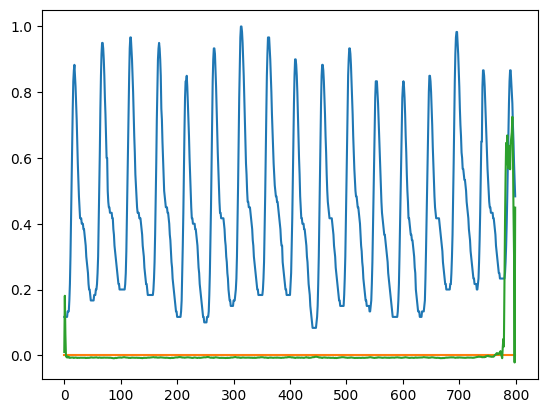

0.008038256


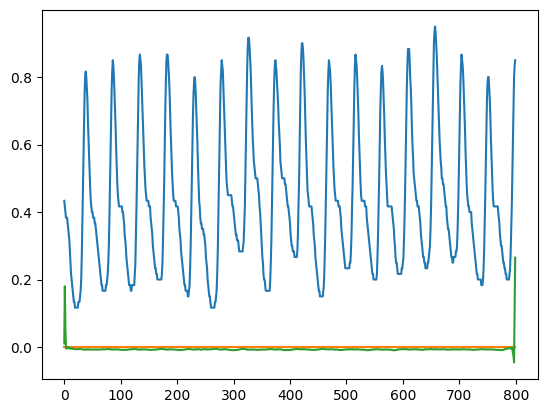

0.0075711184


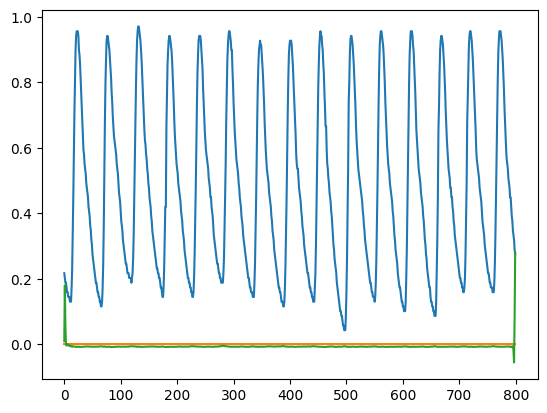

0.0076427087


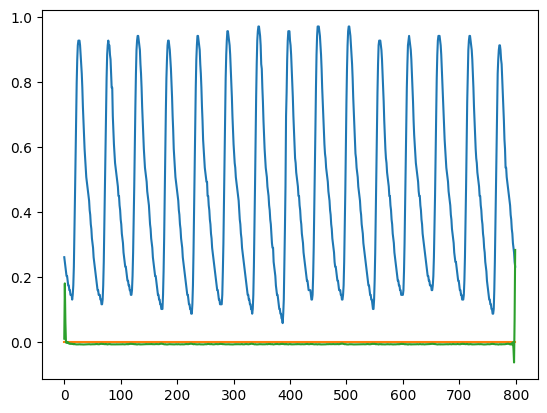

0.007659427


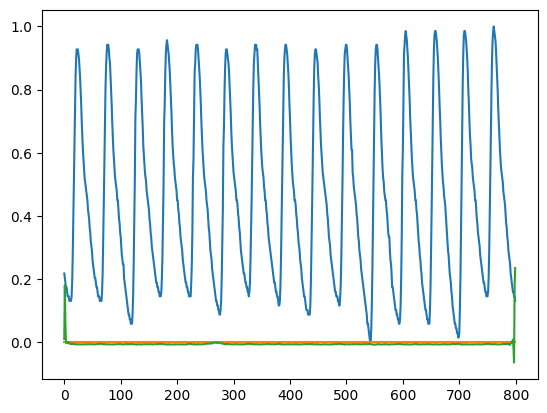

0.007629652


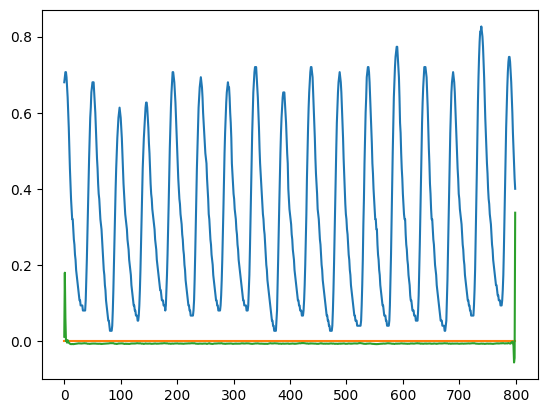

0.105392985


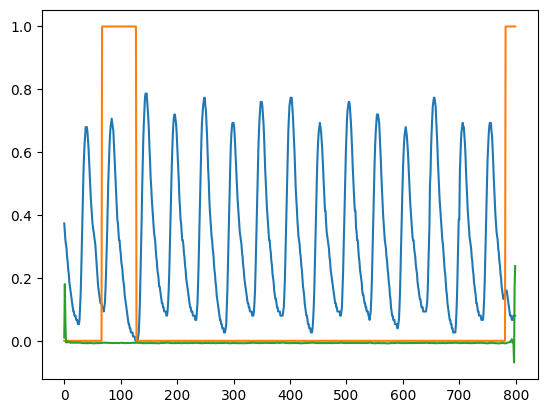

0.96531004


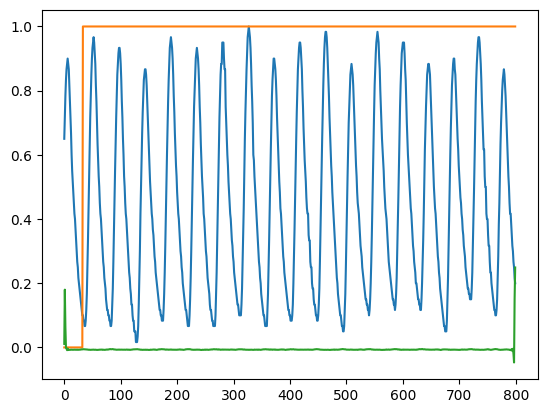

0.9893749


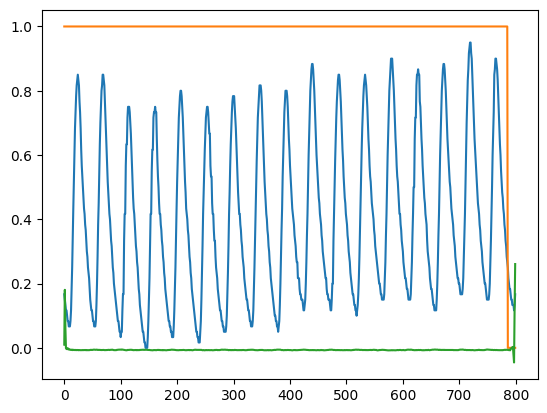

C:\Users\Admin\AppData\Local\Temp\ipykernel_11064\2016691289.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
D:\ppg_project/code/model_build/my_tool/tool/data_load\ppg_labeled_load.py:83: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = "AR")


IndexError: list index out of range

In [6]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(100):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()